<class 'pandas.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   invoice_and_item_number  78 non-null     str           
 1   date                     78 non-null     datetime64[us]
 2   store_number             78 non-null     int64         
 3   store_name               78 non-null     str           
 4   address                  78 non-null     str           
 5   city                     78 non-null     str           
 6   zip_code                 78 non-null     float64       
 7   store_location           69 non-null     str           
 8   county_number            77 non-null     float64       
 9   county                   77 non-null     str           
 10  category                 75 non-null     float64       
 11  category_name            69 non-null     str           
 12  vendor_number            78 non-null     float64 

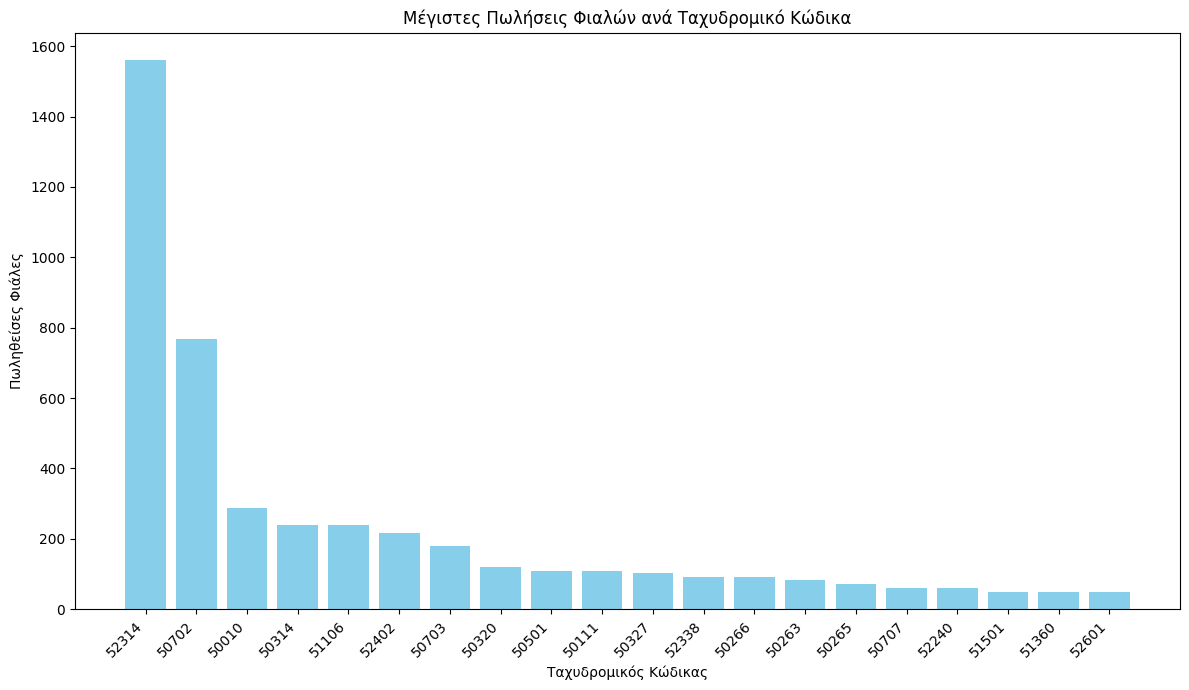

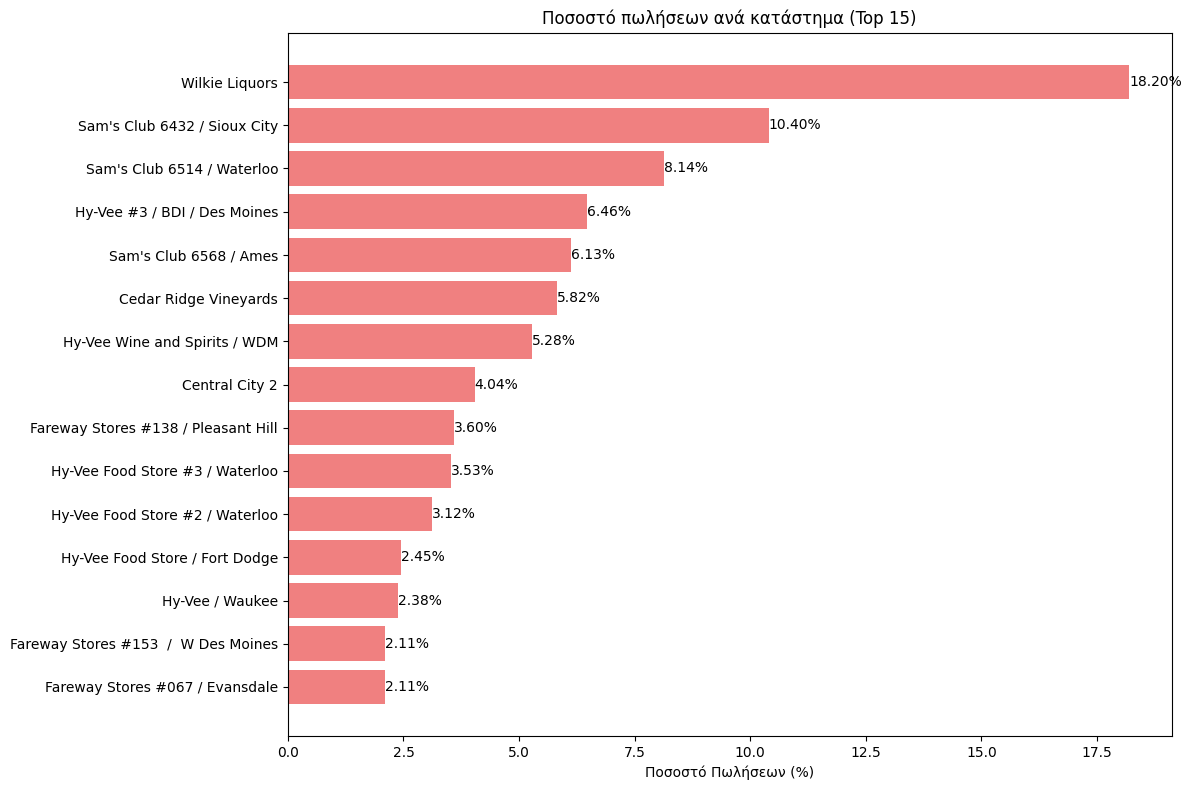

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import seaborn as sns
df = df_liquor = pd.read_csv('finance_liquor_sales.csv')
#FILTER AND CLEANING

#DATE -> DATETIME
df["date"] = pd.to_datetime(df["date"])
# Remove the extra outer brackets and use () for each condition
filtered_df = df[(df["date"].dt.year >= 2016) & (df["date"].dt.year <= 2019)].reset_index(drop=True)
bottles_sold = filtered_df.groupby(["zip_code", "item_number"])["bottles_sold"].sum().reset_index()
filtered_df.info()
#ERGASIA A 
bottles_sold["zip_code"] = bottles_sold["zip_code"].astype(int)
idx = bottles_sold.groupby("zip_code")["bottles_sold"].idxmax()
max_bottles = bottles_sold.loc[idx].reset_index()
sorted_values = max_bottles.sort_values(by="bottles_sold", ascending=False).head(20)
plt.figure(figsize=(12, 7))
plt.bar(sorted_values["zip_code"].astype(str), sorted_values["bottles_sold"], color="skyblue")
plt.xlabel("Ταχυδρομικός Κώδικας")
plt.ylabel("Πωληθείσες Φιάλες")
plt.title("Μέγιστες Πωλήσεις Φιαλών ανά Ταχυδρομικό Κώδικα")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
#ERGASIA B
# Συνολικές πωλήσεις
total_sales = filtered_df["sale_dollars"].sum()
# Ομαδοποίηση ανά κατάστημα
sales_by_store = filtered_df.groupby("store_name")["sale_dollars"].sum()
#Ποσοστό
percentage_sales = (sales_by_store * 100 / total_sales).round(2)
top_15_stores = percentage_sales.sort_values(ascending=False).head(15)
plt.figure(figsize=(12, 8))
p = plt.barh(top_15_stores.index, top_15_stores.values, color='lightcoral')
plt.xlabel("Ποσοστό Πωλήσεων (%)")
plt.title("Ποσοστό πωλήσεων ανά κατάστημα (Top 15)")
plt.gca().invert_yaxis()
plt.bar_label(p, fmt="%.2f%%")
plt.tight_layout()
plt.show()

Πραγματοπιήθηκε Προετοιμασία και καθαρισμός των δεδομένων μεσω Python καθώς χρησιμοποιήσαμε και την Pandas για την ανάληση δημοφιλών ειδών Και εγινε σχεδιασμος γραφημάτων μέσω της Matplotlib.
Στο Πρώτο γράφημα παρατηρούμε οτι οι μέγιστες πωλήσεις ανά Ταχυδρομικό κώδικα είναι στον ΤΚ 52314 Με  1500 πωλήσεις φιαλών σχεδόν διπλάσια απο την δέυτερη περιοχή.Ο 52601 ηταν ο ΤΚ Με τις χαμηλότερες πωλήσεις φιαλών με κάτω απο 200 φιάλες.Τελος παρατήρουμε οτι οι γενικες πωλήσεις φιαλων ανα ταχυδρομικό κωδικα έχουν καθοδική πορεία και κυμενονται 100-200 φιάλες
Τέλος οι εφοδιαστική αλύσίδα θα πρέπει να δωσεί προτερεότητα στον ΤΚ 52314 Για αποφυγή ελλείψεων σε φιάλες .

Στο δεύτερο γράφημα Παρατηρούμε τις Τοπ 15 πωλήσεις ανά κατάστημα.Το κατάστημα με τις μεγαλύτερες πωλήσεις ειναι το Wikiee Liquors  με ποσοστό στην αγορα 18,20% .Το κατάστημα με τις λιγότερες πωλήσεις ειναι το Fareway Stores 067 / Evansdale με ποσοστο 2,11 %.Επίσης βλέπουμε οτι τα πρώτα 3 καταστήματα (Wilie Liquors, Sams Club) κατέχουν το 37% και δίχνει ότι έχουμε μεγάλο αριθμο πωλήσεων σε συγκεκριμένα σημεία.Τέλος βλέπουμε οτι μεγάλο μέρος της αγόρας τον εχουν συγκεκριμένες αλυσήδες όπως το Sams Club , Hy-Vee,επειδή εμφανίζονται επανειλημμένα στην λίστα επιβεβαιώνοντας την κυριαρχία τους στο δυκτιο διανομής.
Τέλος συνδιάζοντας τα 2 γραφήματα βλέπουμε οτι  οι επιτυχία των πωλήσεων ωφείλεται σε σε συγκεκριμένα γεωγραφικά σημεία αλλα και σε συνεργασιες με καταστήματα οπως το Wilkie Liquors
